In [ ]:
!pip -q install mediapipe opencv-python tqdm tensorflow scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 4.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.flush_and_unmount()

!rm -rf /content/drive
!mkdir -p /content/drive


Drive not mounted, so nothing to flush and unmount.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
print("MyDrive:", os.listdir("/content/drive/MyDrive")[:50])


MyDrive: ['Classroom', 'AbhimatDangi_24152352', 'Colab Notebooks', 'AbhimatDangi_24152352.zip', 'Abhimat Dangi branding.gdoc', 'MLOPS', 'Week1_ColabIntro (1).gdoc', 'Week1_ColabIntro.gdoc', 'format_framix.gdoc', 'hc1.mp4', 'e1.png', 'e2.png', 'e3.png', 'e4.png', 'John VSL ', '1 (1).gdoc', '1.gdoc', 'Editing_Backup', 'NayaRoop-Features&TaskDivision.gsheet', 'datasets', 'face_shape_project', 'Abhimat_Dangi_24152352.gdoc', 'dataset', 'dataset_processed_224']


In [ ]:
print(os.listdir("/content/drive/MyDrive/dataset"))


['training_set', 'testing_set']


In [ ]:
RAW_DIR  = "/content/drive/MyDrive/dataset"
PROC_DIR = "/content/drive/MyDrive/dataset_processed_224"


In [ ]:
import os, cv2, math
from tqdm import tqdm
import mediapipe as mp
import mediapipe.solutions as mp_solutions # Explicitly import mediapipe.solutions

RAW_DIR  = "/content/drive/MyDrive/dataset"
PROC_DIR = "/content/drive/MyDrive/dataset_processed_224"

IMG_SIZE = 224
TOP_MARGIN = 0.35
BOTTOM_MARGIN = 0.60
SIDE_MARGIN = 0.28
EXTS = (".jpg",".jpeg",".png",".webp")

os.makedirs(PROC_DIR, exist_ok=True);

mp_face_mesh = mp_solutions.face_mesh  # Use mp_solutions instead of mp.solutions

def clamp(v, lo, hi): return max(lo, min(hi, v))

def rotate(img, angle, center):
    h,w = img.shape[:2]
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(img, M, (w,h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE), M

def apply(M,x,y):
    return (M[0,0]*x+M[0,1]*y+M[0,2],
            M[1,0]*x+M[1,1]*y+M[1,2])

def preprocess_one(fm, img):
    h,w = img.shape[:2]
    res = fm.process(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    if not res.multi_face_landmarks:
        return None

    lms = res.multi_face_landmarks[0].landmark
    pts = [(p.x*w, p.y*h) for p in lms]

    # align by outer eye corners
    lx,ly = pts[33]
    rx,ry = pts[263]
    angle = math.degrees(math.atan2(ry-ly, rx-lx))

    rot, M = rotate(img, -angle, (w/2, h/2))
    rpts = [apply(M,x,y) for x,y in pts]
    xs, ys = zip(*rpts)
    x1,y1,x2,y2 = min(xs),min(ys),max(xs),max(ys)
    fw, fh = x2-x1, y2-y1
    if fw <= 2 or fh <= 2:
        return None

    nx1 = int(clamp(x1 - SIDE_MARGIN*fw, 0, w-1))
    nx2 = int(clamp(x2 + SIDE_MARGIN*fw, 0, w-1))
    ny1 = int(clamp(y1 - TOP_MARGIN*fh, 0, h-1))
    ny2 = int(clamp(y2 + BOTTOM_MARGIN*fh, 0, h-1))

    if nx2 <= nx1 or ny2 <= ny1:
        return None

    crop = rot[ny1:ny2, nx1:nx2]
    if crop.size == 0:
        return None

    return cv2.resize(crop, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

def run_split(split):
    src = os.path.join(RAW_DIR, split)
    dst = os.path.join(PROC_DIR, split)
    os.makedirs(dst, exist_ok=True)

    classes = [d for d in os.listdir(src) if os.path.isdir(os.path.join(src, d))]
    for c in classes:
        os.makedirs(os.path.join(dst, c), exist_ok=True)

    saved = failed = skipped = 0

    with mp_solutions.FaceMesh(
        static_image_mode=True,
        max_num_faces=1,
        refine_landmarks=True,
        min_detection_confidence=0.5
    ) as fm:
        for c in classes:
            in_cls = os.path.join(src, c)
            out_cls = os.path.join(dst, c)

            files = [f for f in os.listdir(in_cls) if f.lower().endswith(EXTS)]
            for f in tqdm(files, desc=f"{split}/{c}"):
                out_path = os.path.join(out_cls, os.path.splitext(f)[0] + ".jpg")

                # resume support
                if os.path.exists(out_path):
                    skipped += 1
                    continue

                img = cv2.imread(os.path.join(in_cls, f))
                if img is None:
                    failed += 1
                    continue

                out = preprocess_one(fm, img)
                if out is None:
                    failed += 1
                    continue

                if cv2.imwrite(out_path, out):
                    saved += 1
                else:
                    failed += 1

    print(f"[{split}] saved={saved} skipped={skipped} failed={failed}")

run_split("training_set")
run_split("testing_set")
print("✅ Done. Saved to:", PROC_DIR)

AttributeError: module 'mediapipe' has no attribute 'solutions'

In [ ]:
import tensorflow as tf
import os

PROC_DIR = "/content/drive/MyDrive/dataset_processed_224"
IMG_SIZE = (224, 224)
BATCH = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PROC_DIR, "training_set"),
    image_size=IMG_SIZE,
    batch_size=BATCH,
    seed=SEED,
    label_mode="categorical",
    shuffle=True,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PROC_DIR, "testing_set"),
    image_size=IMG_SIZE,
    batch_size=BATCH,
    seed=SEED,
    label_mode="categorical",
    shuffle=False,
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 4000 files belonging to 5 classes.
Found 1000 files belonging to 5 classes.
Classes: ['Heart', 'Oblong', 'Oval', 'Round', 'Square']


In [ ]:
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
import tensorflow as tf

aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="aug")

base = EfficientNetB0(include_top=False, input_shape=IMG_SIZE + (3,), weights="imagenet")
base.trainable = False  # stage 1

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = aug(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

best_path = "/content/drive/MyDrive/face_shape_best.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(best_path, save_best_only=True, monitor="val_accuracy", mode="max"),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_accuracy"),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, monitor="val_loss"),
]

print("=== Stage 1: Train head (base frozen) ===")
hist1 = model.fit(train_ds, validation_data=test_ds, epochs=15, callbacks=callbacks)

print("Saved best model to:", best_path)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
=== Stage 1: Train head (base frozen) ===
Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1651s 13s/step - accuracy: 0.2284 - loss: 1.6671 - val_accuracy: 0.3400 - val_loss: 1.5037 - learning_rate: 0.0010
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 152ms/step - accuracy: 0.3331 - loss: 1.5171 - val_accuracy: 0.3730 - val_loss: 1.4641 - learning_rate: 0.0010
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 156ms/step - accuracy: 0.3779 - loss: 1.4596 - val_accuracy: 0.3880 - val_loss: 1.4386 - learning_rate: 0.0010
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 153ms/step - accuracy: 0.3888 - loss: 1.4369 - val_accuracy: 0.3970 - val_loss: 1.4238 - learning_rate: 0.0010
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 154ms/step - accuracy: 0.4058 - loss: 1.4079 - val_accuracy: 0.4020 - val_loss: 1.4105 - learning_rate: 0.0010
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 148ms/step - accuracy: 0.4108 - loss: 1.3959 - val_accuracy: 0.3980 - val_loss: 1.4018 -

In [ ]:
import tensorflow as tf

# Unfreeze more of the backbone
base.trainable = True

# Freeze only the very early layers (keep low-level edges stable)
for layer in base.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-6),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/face_shape_best.keras",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max",
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=6,
        restore_best_weights=True,
        monitor="val_accuracy",
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        patience=2,
        factor=0.5,
        monitor="val_loss",
        min_lr=5e-7,
    ),
]

print("=== Stage 2: stronger fine-tune ===")
hist2 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=25,
    callbacks=callbacks,
)

model.save("/content/drive/MyDrive/face_shape_final.keras")
print("✅ Saved final model to Drive")


=== Stage 2: stronger fine-tune ===
Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 187ms/step - accuracy: 0.4649 - loss: 1.3212 - val_accuracy: 0.4640 - val_loss: 1.3338 - learning_rate: 3.0000e-06
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 178ms/step - accuracy: 0.4776 - loss: 1.3147 - val_accuracy: 0.4680 - val_loss: 1.3306 - learning_rate: 3.0000e-06
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 176ms/step - accuracy: 0.4872 - loss: 1.3137 - val_accuracy: 0.4700 - val_loss: 1.3280 - learning_rate: 3.0000e-06
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 165ms/step - accuracy: 0.5029 - loss: 1.2844 - val_accuracy: 0.4710 - val_loss: 1.3259 - learning_rate: 3.0000e-06
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 164ms/step - accuracy: 0.4861 - loss: 1.2990 - val_accuracy: 0.4710 - val_loss: 1.3235 - learning_rate: 3.0000e-06
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 161ms/step - accuracy: 0.4889 - loss: 1.2940 - val_accuracy: 0.4740 - val_loss: 1.3211 - learning_rate: 3.0000e-06
Epoch 7/25

In [ ]:
import tensorflow as tf
import os

PROC_DIR = "/content/drive/MyDrive/dataset_processed_224"

# Re-load ONLY to get class names (fast, no training)
tmp_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PROC_DIR, "training_set"),
    image_size=(224,224),
    batch_size=32,
    label_mode="categorical",
    shuffle=False,
)

class_names = tmp_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("num_classes:", num_classes)
del tmp_ds


Found 4000 files belonging to 5 classes.
Classes: ['Heart', 'Oblong', 'Oval', 'Round', 'Square']
num_classes: 5


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = (224, 224)

aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.06),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.10),
], name="aug")

base = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    input_shape=IMG_SIZE + (3,),
    weights="imagenet",
)
base.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = aug(inputs)
x = tf.keras.applications.efficientnet_v2.preprocess_input(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model_v2 = tf.keras.Model(inputs, outputs)

model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/face_shape_v2_best.keras",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max",
    ),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_accuracy"),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, monitor="val_loss"),
]

print("=== V2 Stage 1 (frozen backbone) ===")
hist1_v2 = model_v2.fit(train_ds, validation_data=test_ds, epochs=15, callbacks=callbacks)


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
=== V2 Stage 1 (frozen backbone) ===
Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 205ms/step - accuracy: 0.2334 - loss: 1.6372 - val_accuracy: 0.2930 - val_loss: 1.5343 - learning_rate: 0.0010
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 165ms/step - accuracy: 0.3521 - loss: 1.5153 - val_accuracy: 0.3410 - val_loss: 1.5086 - learning_rate: 0.0010
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 162ms/step - accuracy: 0.3730 - loss: 1.4723 - val_accuracy: 0.3730 - val_loss: 1.4628 - learning_rate: 0.0010
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 154ms/step - accuracy: 0.3997 - loss: 1.4361 - val_accuracy: 0.3930 - val_loss: 1.4490 - learning_rate: 0.0010
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 155ms/step - accuracy: 0.4239 - loss: 1.4104 - val_accuracy: 0.4000 - val_loss: 1.4380 - learning_rate: 0.0010
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 145ms/step - accuracy: 0.4295 - loss: 1.3997 - val_accuracy: 0.3980 - val_loss: 1.4225 - lear

In [ ]:
import tensorflow as tf

# Unfreeze backbone for fine-tuning
base.trainable = True

# Freeze early layers only (keep low-level edges stable)
for layer in base.layers[:120]:
    layer.trainable = False

# Re-compile with a very small LR
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-6),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)

print("=== V2 Stage 2 (fine-tune) ===")
hist2_v2 = model_v2.fit(
    train_ds,
    validation_data=test_ds,
    epochs=25,
    callbacks=callbacks,
)

model_v2.save("/content/drive/MyDrive/face_shape_v2_final.keras")
print("✅ Saved: /content/drive/MyDrive/face_shape_v2_final.keras")


=== V2 Stage 2 (fine-tune) ===
Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 61s 225ms/step - accuracy: 0.3026 - loss: 1.6098 - val_accuracy: 0.3200 - val_loss: 1.5534 - learning_rate: 3.0000e-06
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 25s 202ms/step - accuracy: 0.3085 - loss: 1.5661 - val_accuracy: 0.3330 - val_loss: 1.5247 - learning_rate: 3.0000e-06
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 200ms/step - accuracy: 0.3248 - loss: 1.5404 - val_accuracy: 0.3420 - val_loss: 1.5033 - learning_rate: 3.0000e-06
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 195ms/step - accuracy: 0.3510 - loss: 1.5206 - val_accuracy: 0.3610 - val_loss: 1.4866 - learning_rate: 3.0000e-06
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 191ms/step - accuracy: 0.3779 - loss: 1.5081 - val_accuracy: 0.3650 - val_loss: 1.4655 - learning_rate: 3.0000e-06
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 208ms/step - accuracy: 0.3530 - loss: 1.4926 - val_accuracy: 0.3700 - val_loss: 1.4577 - learning_rate: 3.0000e-06
Epoch 7/25
125/

In [ ]:
import tensorflow as tf
import os

PROC_DIR = "/content/drive/MyDrive/dataset_processed_224"  # keep same folder
IMG_SIZE = (260, 260)
BATCH = 32
SEED = 42

train_ds_260 = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PROC_DIR, "training_set"),
    image_size=IMG_SIZE,
    batch_size=BATCH,
    seed=SEED,
    label_mode="categorical",
    shuffle=True,
)

test_ds_260 = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PROC_DIR, "testing_set"),
    image_size=IMG_SIZE,
    batch_size=BATCH,
    seed=SEED,
    label_mode="categorical",
    shuffle=False,
)

class_names = train_ds_260.class_names
num_classes = len(class_names)
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds_260 = train_ds_260.prefetch(AUTOTUNE)
test_ds_260  = test_ds_260.prefetch(AUTOTUNE)


Found 4000 files belonging to 5 classes.
Found 1000 files belonging to 5 classes.
Classes: ['Heart', 'Oblong', 'Oval', 'Round', 'Square']


In [ ]:
from tensorflow.keras import layers
import tensorflow as tf

aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.04),   # smaller than before
    layers.RandomZoom(0.05),       # smaller than before
    layers.RandomContrast(0.08),
], name="aug")

base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=IMG_SIZE + (3,),
    weights="imagenet",
)
base.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = aug(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model_260 = tf.keras.Model(inputs, outputs)

model_260.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/face_shape_b0_260_best.keras",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max",
    ),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_accuracy"),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, monitor="val_loss"),
]

print("=== B0 260 Stage 1 (frozen) ===")
hist1 = model_260.fit(train_ds_260, validation_data=test_ds_260, epochs=15, callbacks=callbacks)

=== B0 260 Stage 1 (frozen) ===
Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 37s 219ms/step - accuracy: 0.2582 - loss: 1.6361 - val_accuracy: 0.3340 - val_loss: 1.5134 - learning_rate: 0.0010
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 163ms/step - accuracy: 0.3258 - loss: 1.5287 - val_accuracy: 0.3670 - val_loss: 1.4876 - learning_rate: 0.0010
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 181ms/step - accuracy: 0.3819 - loss: 1.4693 - val_accuracy: 0.3780 - val_loss: 1.4630 - learning_rate: 0.0010
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 168ms/step - accuracy: 0.4018 - loss: 1.4459 - val_accuracy: 0.4010 - val_loss: 1.4522 - learning_rate: 0.0010
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 174ms/step - accuracy: 0.4201 - loss: 1.4122 - val_accuracy: 0.3870 - val_loss: 1.4465 - learning_rate: 0.0010
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 165ms/step - accuracy: 0.4110 - loss: 1.4107 - val_accuracy: 0.3970 - val_loss: 1.4348 - learning_rate: 0.0010
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━

In [ ]:
# Unfreeze more backbone than before
base.trainable = True
for layer in base.layers[:120]:
    layer.trainable = False

# Step A: faster fine-tune (few epochs)
model_260.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)

print("=== B0 260 Stage 2A (lr=1e-5) ===")
hist2a = model_260.fit(train_ds_260, validation_data=test_ds_260, epochs=5, callbacks=callbacks)

# Step B: polish (lower LR)
model_260.compile(
    optimizer=tf.keras.optimizers.Adam(3e-6),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
)

print("=== B0 260 Stage 2B (lr=3e-6) ===")
hist2b = model_260.fit(train_ds_260, validation_data=test_ds_260, epochs=20, callbacks=callbacks)

model_260.save("/content/drive/MyDrive/face_shape_b0_260_final.keras")
print("✅ Saved: face_shape_b0_260_final.keras")


=== B0 260 Stage 2A (lr=1e-5) ===
Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 63s 284ms/step - accuracy: 0.2956 - loss: 1.6554 - val_accuracy: 0.3950 - val_loss: 1.4504 - learning_rate: 1.0000e-05
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 262ms/step - accuracy: 0.3423 - loss: 1.5421 - val_accuracy: 0.4150 - val_loss: 1.4183 - learning_rate: 1.0000e-05
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 251ms/step - accuracy: 0.3962 - loss: 1.4546 - val_accuracy: 0.4360 - val_loss: 1.3825 - learning_rate: 1.0000e-05
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 268ms/step - accuracy: 0.4231 - loss: 1.4075 - val_accuracy: 0.4490 - val_loss: 1.3486 - learning_rate: 1.0000e-05
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 262ms/step - accuracy: 0.4591 - loss: 1.3585 - val_accuracy: 0.4570 - val_loss: 1.3209 - learning_rate: 1.0000e-05
=== B0 260 Stage 2B (lr=3e-6) ===
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 61s 288ms/step - accuracy: 0.4755 - loss: 1.3268 - val_accuracy: 0.4610 - val_loss: 1.3108 - learning_

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = np.concatenate([y.numpy().argmax(axis=1) for x, y in test_ds_260], axis=0)
y_pred = np.concatenate([model_260.predict(x, verbose=0).argmax(axis=1) for x, y in test_ds_260], axis=0)

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:\n", cm)
print("\nReport:\n", classification_report(y_true, y_pred, target_names=class_names))


Confusion matrix:
 [[ 94  46  20  12  28]
 [ 12 160   8   4  16]
 [ 33  32  63  30  42]
 [  8  14  24 107  47]
 [  9  33  13  11 134]]

Report:
               precision    recall  f1-score   support

       Heart       0.60      0.47      0.53       200
      Oblong       0.56      0.80      0.66       200
        Oval       0.49      0.32      0.38       200
       Round       0.65      0.54      0.59       200
      Square       0.50      0.67      0.57       200

    accuracy                           0.56      1000
   macro avg       0.56      0.56      0.55      1000
weighted avg       0.56      0.56      0.55      1000



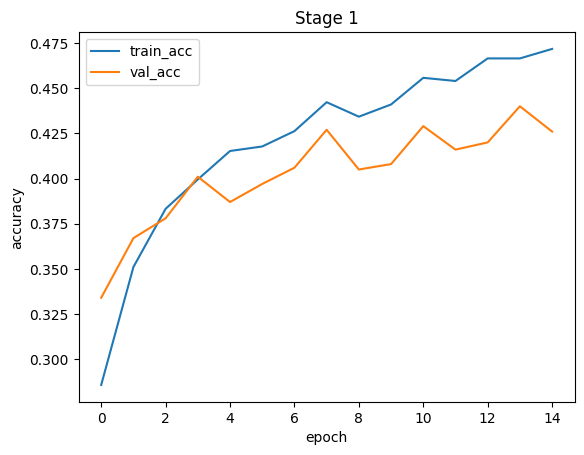

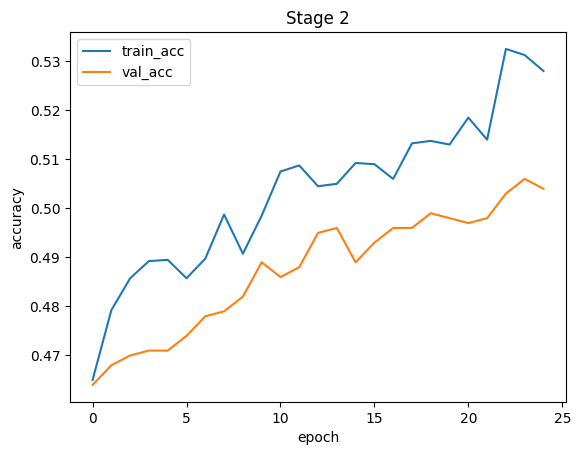

In [ ]:
import matplotlib.pyplot as plt

def plot_hist(hist, title):
    plt.figure()
    plt.plot(hist.history["accuracy"], label="train_acc")
    plt.plot(hist.history["val_accuracy"], label="val_acc")
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.legend()
    plt.show()

plot_hist(hist1, "Stage 1")
plot_hist(hist2, "Stage 2")


In [ ]:
!pip install -q face-alignment torch torchvision


In [ ]:
import cv2, math, numpy as np
import face_alignment
import torch

IMG_SIZE = 260
TOP_MARGIN = 0.35
BOTTOM_MARGIN = 0.60
SIDE_MARGIN = 0.28

device = "cuda" if torch.cuda.is_available() else "cpu"
fa = face_alignment.FaceAlignment(
    face_alignment.LandmarksType.TWO_D,
    device=device,
    flip_input=False
)

print("face-alignment device:", device)


Downloading: "https://www.adrianbulat.com/downloads/python-fan/s3fd-619a316812.pth" to /root/.cache/torch/hub/checkpoints/s3fd-619a316812.pth


100%|██████████| 85.7M/85.7M [00:08<00:00, 10.0MB/s]
Downloading: "https://www.adrianbulat.com/downloads/python-fan/2DFAN4-cd938726ad.zip" to /root/.cache/torch/hub/checkpoints/2DFAN4-cd938726ad.zip
100%|██████████| 91.9M/91.9M [00:07<00:00, 12.5MB/s]


face-alignment device: cuda


In [ ]:
import cv2, math, numpy as np
import face_alignment
import torch

IMG_SIZE = 260
TOP_MARGIN = 0.35
BOTTOM_MARGIN = 0.60
SIDE_MARGIN = 0.28

device = "cuda" if torch.cuda.is_available() else "cpu"
fa = face_alignment.FaceAlignment(
    face_alignment.LandmarksType.TWO_D,
    device=device,
    flip_input=False
)

print("face-alignment device:", device)

def clamp(v, lo, hi):
    return max(lo, min(hi, v))

def rotate(img, angle, center):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    out = cv2.warpAffine(img, M, (w, h),
                         flags=cv2.INTER_LINEAR,
                         borderMode=cv2.BORDER_REPLICATE)
    return out, M

def apply(M, x, y):
    return (
        M[0,0]*x + M[0,1]*y + M[0,2],
        M[1,0]*x + M[1,1]*y + M[1,2]
    )

def crop_face(img_bgr):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    lms_list = fa.get_landmarks(img_rgb)
    if not lms_list:
        return None

    lms = lms_list[0]  # largest face
    h, w = img_bgr.shape[:2]

    # eye centers
    left_eye = lms[36:42].mean(axis=0)
    right_eye = lms[42:48].mean(axis=0)

    angle = math.degrees(math.atan2(
        right_eye[1] - left_eye[1],
        right_eye[0] - left_eye[0]
    ))

    rot, M = rotate(img_bgr, -angle, (w/2, h/2))
    rpts = np.array([apply(M, x, y) for x, y in lms])

    x1, y1 = rpts.min(axis=0)
    x2, y2 = rpts.max(axis=0)
    fw, fh = x2 - x1, y2 - y1
    if fw < 5 or fh < 5:
        return None

    nx1 = int(clamp(x1 - SIDE_MARGIN*fw, 0, w))
    nx2 = int(clamp(x2 + SIDE_MARGIN*fw, 0, w))
    ny1 = int(clamp(y1 - TOP_MARGIN*fh, 0, h))
    ny2 = int(clamp(y2 + BOTTOM_MARGIN*fh, 0, h))

    crop = rot[ny1:ny2, nx1:nx2]
    if crop.size == 0:
        return None

    crop = cv2.resize(crop, (IMG_SIZE, IMG_SIZE))
    return crop


face-alignment device: cuda


In [ ]:
import numpy as np
import tensorflow as tf

MODEL_PATH = "/content/drive/MyDrive/face_shape_b0_260_final.keras"
model = tf.keras.models.load_model(MODEL_PATH)

class_names = ["Heart", "Oblong", "Oval", "Round", "Square"]  # VERIFY order!

def predict_face_shape(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Image not found")

    face = crop_face(img)
    if face is None:
        raise ValueError("No face detected")

    x = face.astype(np.float32) / 255.0
    x = np.expand_dims(x, axis=0)

    probs = model.predict(x, verbose=0)[0]
    order = probs.argsort()[::-1]
    top2 = [(class_names[i], float(probs[i])) for i in order[:2]]
    return top2, probs


In [ ]:
img_path = "/content/drive/MyDrive/dataset/testing_set/Heart/heart (101).jpg"
top2, probs = predict_face_shape(img_path)
print("Top-2 face shapes:", top2)


Top-2 face shapes: [('Oblong', 0.2054462730884552), ('Heart', 0.2029869109392166)]


In [ ]:
import os
PROC_DIR = "/content/drive/MyDrive/dataset_processed_224"
print("Real class folder order (sorted):")
print(sorted(os.listdir(f"{PROC_DIR}/training_set")))


Real class folder order (sorted):
['Heart', 'Oblong', 'Oval', 'Round', 'Square']


In [ ]:
for i, p in enumerate(probs):
    print(f"{class_names[i]:<8}: {p:.3f}")


Heart   : 0.203
Oblong  : 0.205
Oval    : 0.197
Round   : 0.200
Square  : 0.195


In [ ]:
import numpy as np
import cv2

# ✅ confirmed correct order from folders
class_names = ["Heart", "Oblong", "Oval", "Round", "Square"]

STYLE_LIBRARY = {
    "Round":  {"best":["High fade + textured top","Short quiff (controlled height)","Side part with volume"],
               "avoid":["Heavy straight fringe","Bowl / very rounded cuts"],
               "note":"Add height and angles to reduce roundness."},

    "Square": {"best":["Crew cut / Ivy League","Textured crop + mid fade","Side part taper"],
               "avoid":["Ultra boxy flat-top"],
               "note":"Strong jaw works best with texture and clean structure."},

    "Oblong": {"best":["Textured fringe (light)","Curtains / medium layered cut","Low taper + natural top"],
               "avoid":["High pompadour","Very tall top with high fade"],
               "note":"Reduce face length; avoid excess height."},

    "Heart":  {"best":["Side-swept fringe","Textured crop (medium height)","Low taper + layered top"],
               "avoid":["Tight sides with huge top volume"],
               "note":"Soften wide forehead; keep top balanced."},

    "Oval":   {"best":["Textured crop","Side part (moderate volume)","Curtains"],
               "avoid":["Extreme height styles"],
               "note":"Balanced face—most styles work, avoid extremes."},
}

def recommend_hairstyles(top2):
    (s1, p1), (s2, p2) = top2
    p_sum = (p1 + p2) if (p1 + p2) > 0 else 1.0
    w1, w2 = p1/p_sum, p2/p_sum

    scores = {}
    for style in STYLE_LIBRARY[s1]["best"]:
        scores[style] = scores.get(style, 0.0) + 1.0*w1
    for style in STYLE_LIBRARY[s2]["best"]:
        scores[style] = scores.get(style, 0.0) + 1.0*w2

    recs = [k for k,_ in sorted(scores.items(), key=lambda x: x[1], reverse=True)[:3]]
    avoid = list(dict.fromkeys(STYLE_LIBRARY[s1]["avoid"] + STYLE_LIBRARY[s2]["avoid"]))
    why = [f"{s1}: {STYLE_LIBRARY[s1]['note']}", f"{s2}: {STYLE_LIBRARY[s2]['note']}"]
    return recs, avoid, why

def predict_and_recommend(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Image not found / unreadable")

    face = crop_face(img)   # face-alignment crop
    if face is None:
        raise ValueError("No face detected")

    # ✅ IMPORTANT: keep 0–255 range (NO /255)
    x = face.astype(np.float32)
    x = np.expand_dims(x, axis=0)

    probs = model.predict(x, verbose=0)[0]
    order = probs.argsort()[::-1]
    top2 = [(class_names[i], float(probs[i])) for i in order[:2]]

    recs, avoid, why = recommend_hairstyles(top2)

    return {
        "top2_shapes": top2,
        "all_probs": {class_names[i]: float(probs[i]) for i in range(len(class_names))},
        "recommended": recs,
        "avoid": avoid,
        "why": why
    }


In [ ]:
img_path = "/content/drive/MyDrive/face_shape_project/square (147).jpg"  # or any square image
result = predict_and_recommend(img_path)

print("Top-2:", result["top2_shapes"])
print("\nAll probs:")
for k,v in result["all_probs"].items():
    print(f"{k:<7}: {v:.3f}")


Top-2: [('Square', 0.4456366002559662), ('Oblong', 0.26488104462623596)]

All probs:
Heart  : 0.089
Oblong : 0.265
Oval   : 0.136
Round  : 0.064
Square : 0.446


In [ ]:
import os, random

FOLDER = "/content/drive/MyDrive/face_shape_project"
exts = (".jpg",".jpeg",".png",".webp")

imgs = [os.path.join(FOLDER,f) for f in os.listdir(FOLDER) if f.lower().endswith(exts)]
random.shuffle(imgs)

for p in imgs[:20]:
    try:
        r = predict_and_recommend(p)
        print("\n===", os.path.basename(p), "===")
        print("Top-2:", r["top2_shapes"])
        print("Recs:", r["recommended"])
    except Exception as e:
        print("\n===", os.path.basename(p), "===")
        print("FAILED:", str(e))



=== square (229).jpg ===
Top-2: [('Oblong', 0.28156137466430664), ('Square', 0.25222817063331604)]
Recs: ['Textured fringe (light)', 'Curtains / medium layered cut', 'Low taper + natural top']

=== square (148).jpg ===
Top-2: [('Oval', 0.2712935209274292), ('Oblong', 0.263310045003891)]
Recs: ['Textured crop', 'Side part (moderate volume)', 'Curtains']

=== square (150).jpg ===
Top-2: [('Square', 0.3863086402416229), ('Oblong', 0.30987614393234253)]
Recs: ['Crew cut / Ivy League', 'Textured crop + mid fade', 'Side part taper']

=== square (158).jpg ===
Top-2: [('Square', 0.2714976370334625), ('Oblong', 0.22284719347953796)]
Recs: ['Crew cut / Ivy League', 'Textured crop + mid fade', 'Side part taper']

=== square (1).jpg ===
Top-2: [('Round', 0.5339820981025696), ('Square', 0.1873866319656372)]
Recs: ['High fade + textured top', 'Short quiff (controlled height)', 'Side part with volume']

=== square (160).jpg ===
Top-2: [('Square', 0.277859628200531), ('Oblong', 0.26899459958076477)]


In [ ]:
import tensorflow as tf
import os

KERAS_PATH = "/content/drive/MyDrive/face_shape_b0_260_final.keras"
TFLITE_PATH = "/content/drive/MyDrive/face_shape_b0_260_final.tflite"

model = tf.keras.models.load_model(KERAS_PATH)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = []  # keep float32 for best accuracy
tflite_model = converter.convert()

with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

print("✅ Saved TFLite:", TFLITE_PATH, "| size:", os.path.getsize(TFLITE_PATH)/1024/1024, "MB")


Saved artifact at '/tmp/tmpej2ido3_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 260, 260, 3), dtype=tf.float32, name='input_layer_7')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  138989687784080: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138989687794064: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138989718231312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138989718232848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138989718233040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138989718237648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138989718235536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138989718230160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138989718235344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138989718231696: TensorSpec(shape=(), dtype=tf.resource, name=Non